In [1]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
import xarray as xr
from ellen_fxns import get_oisst_flag

In [2]:
# Region filter
lat0 = 45
lat1 = 70
lon0 = -85
lon1 = 0

# Depth filter: Only want "surface" values
depth_min = 500

In [3]:
# Setting up parquet schema
parquet_dir = '../shared/go-bgc-2026/data/CrocoLake/BGC_ARGO/'
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

filter_coords_time = [("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
                      ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
                      ("PRES","<",depth_min),
                     ]

df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter_coords_time)
df = df.read().to_pandas()

In [4]:
df = df.assign(MONTH = [pd.Timestamp(ti).month for ti in df.loc[:,'JULD'].values])
df = df.assign(YEAR = [pd.Timestamp(ti).year for ti in df.loc[:,'JULD'].values])

In [5]:
plist = ['MONTH','TEMP','YEAR','PLATFORM_NUMBER','CYCLE_NUMBER']

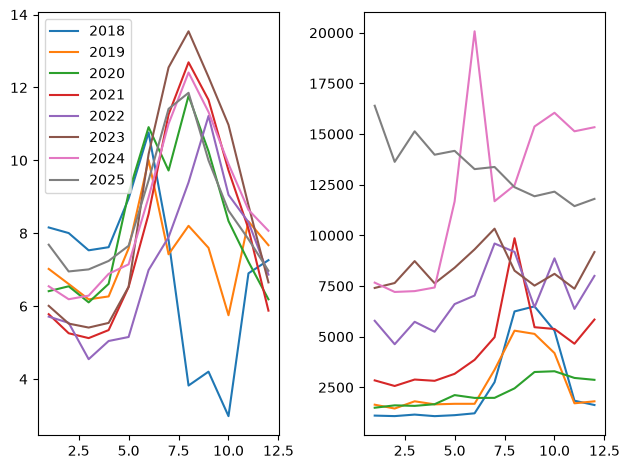

In [6]:
fig = plt.figure()
rr = 1; cc =2

ax1 = fig.add_subplot(rr, cc, 1)
ax2 = fig.add_subplot(rr, cc, 2)

# mean_df = df.loc[:,plist].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean() 

# for year in sorted(df.loc[:,'YEAR'].unique()):
for year in sorted(np.arange(2018, 2026)):
    ax1.plot(df.loc[df.loc[:,'YEAR']==year,plist].groupby(by = 'MONTH').mean().index.values, 
               df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').mean().loc[:,'TEMP'],
               label = year)

    ax2.plot(df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').count().index.values, 
               df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').count().loc[:,'TEMP'],
               label = year)
ax1.legend()

fig.tight_layout()
# plt.scatter(df.loc[df.loc[:,'YEAR']!=2023,plist].groupby('MONTH').mean().index.values, 
#           df.loc[df.loc[:,'YEAR']!=2023,plist].groupby('MONTH').mean().loc[:,'TEMP'])

In [7]:
df.loc[:,'MONTH'].unique()

array([ 5,  6,  7,  8,  9, 10,  4, 11, 12,  1,  2,  3])

In [8]:
df.loc[df.loc[:,'YEAR']==year,plist].groupby('MONTH').count().index.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [9]:
float_data = df.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER', 'LONGITUDE','LATITUDE','JULD']].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean()
float_data

LONGITUDE   LATITUDE  \
PLATFORM_NUMBER CYCLE_NUMBER                         
1901205         1            -19.926143  45.892571   
                2            -18.932000  45.772000   
                3            -18.551000  45.950000   
                4            -18.899000  46.175000   
                5            -19.580000  45.806000   
...                                 ...        ...   
7902390         3            -39.838732  60.049520   
                4            -41.242605  59.539985   
7902418         1            -39.033402  55.809210   
                2            -38.526667  56.067862   
                3            -38.065033  56.403477   

                                                      JULD  
PLATFORM_NUMBER CYCLE_NUMBER                                
1901205         1            2011-07-22 19:11:25.714285824  
                2            2011-08-01 21:52:00.000000000  
                3            2011-08-11 21:58:00.000000000  
                4            2011-08-21 22:04:00.000000000  
                5            2011-08-31 22:04:59.999999744  
...                                                    ...  
7902390         3            2026-07-30 22:11:00.000000000  
                4            2026-08-09 19:51:00.000000000  
7902418         1            2026-07-13 01:26:00.000000000  
                2            2026-07-23 03:57:00.000000000  
                3            2026-08-02 01:11:00.000000000  

[35237 rows x 3 columns]

In [10]:
test = get_oisst_flag(float_data.iloc[:100])

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr


[0.]
1  out of 100
[0.]
2  out of 100
[0.]
3  out of 100
[0.]
4  out of 100


[0.]
5  out of 100
[0.]
6  out of 100
[0.]
7  out of 100
[0.]
8  out of 100


[0.]
9  out of 100
[0.]
10  out of 100
[0.]
11  out of 100
[0.]
12  out of 100
[0.]
13  out of 100


[0.]
14  out of 100
[0.]
15  out of 100
[0.]
16  out of 100
[0.]
17  out of 100
[0.]
18  out of 100


...

[1.]
81  out of 100
[1.]
82  out of 100
[1.]
83  out of 100
[1.]
84  out of 100


[0.]
85  out of 100
[0.]
86  out of 100
[0.]
87  out of 100
[0.]
88  out of 100
[1.]
89  out of 100


[1.]
90  out of 100
[1.]
91  out of 100
[1.]
92  out of 100
[0.]
93  out of 100
[0.]
94  out of 100


[0.]
95  out of 100
[0.]
96  out of 100
[0.]
97  out of 100
[0.]
98  out of 100


[0.]
99  out of 100
[0.]


In [29]:
all_float_data = df.iloc[:1000,:]
oisst_path = 's3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr'
time_name = 'time'
lon_name = 'lon'
lat_name = 'lat'
flag_name = 'mhw_mask'

In [35]:
# Get all locations 
float_data = all_float_data.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER', \
                                   'LONGITUDE','LATITUDE','JULD']].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).mean()

# Load OISST data
# zarr
print('Openining : '+oisst_path)
if oisst_path.split('.')[-1] == 'zarr':
    mhw_data = xr.open_zarr(oisst_path)
elif oisst_path.split('.')[-1] == '.nc':
    mhw_data = xr.open_dataset(oisst_path)

mhw_data.close()

# Make KDTree for nearest neighbor matchups based on MWH mask
XX, YY = np.meshgrid(mhw_data[lon_name].values, mhw_data[lat_name].values)
# xx: lon; yy: lat
tree = KDTree(np.c_[XX.ravel(),YY.ravel()])

mwh_flag = np.zeros(float_data.shape[0])*np.nan
all_mhw_flags = np.zeros(all_float_data.shape[0])*np.nan

# Convert all float date-times to just date
dates = np.array([pd.Timestamp(xi).date() for xi in float_data.loc[:,'JULD'].values], dtype='datetime64')

# Get unique dates
unique_dates = np.unique(dates)

# For each date...
for di, date in enumerate(unique_dates):

    if di%100 == 0:
        print(di, ' out of', float_data.shape[0])
        
    # 1. Get MWH slice for that date
    mhw_i = np.where(mhw_data[time_name].values.astype('datetime64[D]') == date)[0]

    # If the date is in the data range,
    if mhw_i.shape[0] > 0:

        # Subset array
        mhw_mask = mhw_data[flag_name].isel(**{time_name: mhw_i})
        
        # 2. Get all profile locations
        prof_inds = np.where(unique_dates == date)[0]
        lons = (((360 + (float_data.loc[:,'LONGITUDE'].values[prof_inds] % 360)) % 360))
        lats = float_data.loc[:,'LATITUDE'].values[prof_inds]
        
        # 3. Use nearest neighbor to get flag
        for ni in np.arange(day_flags.shape[0]):
        
            # print(ni, lons[ni], lats[ni])
            dd, ii = tree.query([lons[ni], lats[ni]])
            ri, ci = np.unravel_index(ii, XX.shape)

            # Get index for expanded data
            wmo, cycle = float_data.index.values[prof_inds][ni]
            all_inds = all_float_data.loc[(all_float_data.loc[:,'PLATFORM_NUMBER']==wmo) & \
                (all_float_data.loc[:,'CYCLE_NUMBER']==cycle),:].index.values
            

            # 4. Assign flags back to original shape
            all_mhw_flags[all_inds] = mhw_mask[0,ri,ci]

# Add flags to pandas data frame
all_float_data = all_float_data.assign(**{flag_name: all_mhw_flags})

Openining : s3://uw-escience-scratch-prod/oisst/mhw_mask_north_atlantic_final.zarr


0  out of 69
